Shapes: (2000, 100, 100, 3) (2000,)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ densenet121 (Functional)             │ (None, 7, 7, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,173,058 (27.36 MB)

 Trainable params: 774,914 (2.96 MB)

 Non-trainable params: 6,398,144 (24.41 MB)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 881ms/step - accuracy: 0.5360 - loss: 0.6944 - val_accuracy: 0.4800 - val_loss: 0.7495
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 845ms/step - accuracy: 0.5835 - loss: 0.6696 - val_accuracy: 0.4800 - val_loss: 0.7326
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 837ms/step - accuracy: 0.6325 - loss: 0.6490 - val_accuracy: 0.4800 - val_loss: 0.7006
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 847ms/step - accuracy: 0.6405 - loss: 0.6305 - val_accuracy: 0.5300 - val_loss: 0.6911
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 857ms/step - accuracy: 0.6665 - loss: 0.6203 - val_accuracy: 0.5220 - val_loss: 0.6867
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 888ms/step - accuracy: 0.6825 - loss: 0.6041 - val_accuracy: 0.5220 - val_loss: 0.6817
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 53s 839ms/step - accuracy: 0.6915 - loss: 0.5975 - val_accuracy: 0.5200 - val_loss: 0.8695
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 831ms/step - accuracy: 0.7065 - loss: 0.5728 - val_accu

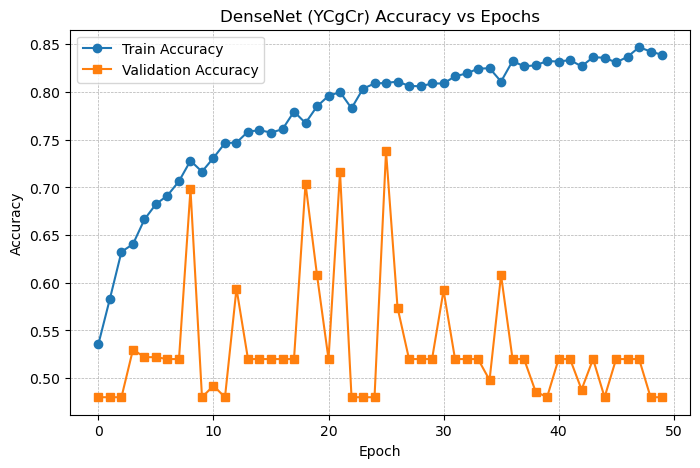

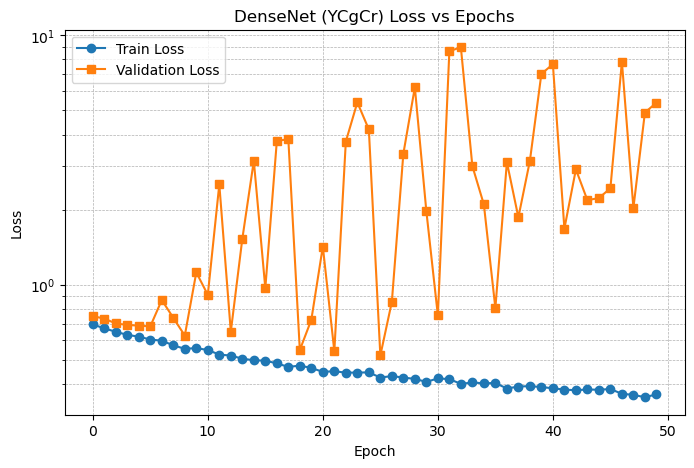

In [5]:
# =========================================
# 1. Imports
# =========================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


# =========================================
# 2. Load Dataset
# =========================================
PATH = "C:/Users/gsama/Desktop/mobinet"

X_train = np.load(f"{PATH}/X_train.npy")
y_train = np.load(f"{PATH}/y_train.npy")
X_test = np.load(f"{PATH}/X_test.npy")
y_test = np.load(f"{PATH}/y_test.npy")

print("Shapes:", X_train.shape, y_train.shape)


# =========================================
# 3. RGB → YCgCr
# =========================================
def rgb_to_ycgcr(img):
    R = img[:,:,:,0]
    G = img[:,:,:,1]
    B = img[:,:,:,2]

    Y  = 0.25*R + 0.5*G + 0.25*B
    Cg = -0.25*R + 0.5*G - 0.25*B
    Cr = 0.5*R - 0.5*B

    return np.stack((Y, Cg, Cr), axis=-1)

X_train = rgb_to_ycgcr(X_train)
X_test = rgb_to_ycgcr(X_test)


# =========================================
# 4. Preprocessing
# =========================================
X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train = tf.image.resize(X_train, (224,224)).numpy()
X_test = tf.image.resize(X_test, (224,224)).numpy()


# =========================================
# 5. Build DenseNet Model
# =========================================
base_model = tf.keras.applications.DenseNet121(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Fine-tuning (more layers trainable for better learning)
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True


# =========================================
# 6. Custom Layers
# =========================================
inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(y_train.shape[1], activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)


# =========================================
# 7. Compile
# =========================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# =========================================
# 8. Train (FULL 50 EPOCHS - NO EARLY STOP)
# =========================================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)


# =========================================
# 9. Save Model
# =========================================
model.save(f"{PATH}/densenet_ycgcr_final.keras")


# =========================================
# 10. Accuracy Plot (with grid)
# =========================================
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='s', label='Validation Accuracy')

plt.title("DenseNet (YCgCr) Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.show()


# =========================================
# 11. Loss Plot (with grid + log scale)
# =========================================
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='s', label='Validation Loss')

plt.title("DenseNet (YCgCr) Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()